In [1]:
!pip install wfdb pywavelets scikit-learn imbalanced-learn tensorflow seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 69.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import entropy
import pywt
import wfdb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, cohen_kappa_score,
    accuracy_score, recall_score, precision_score
)
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import warnings
warnings.filterwarnings('ignore')

print("✓ All packages installed successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

✓ All packages installed successfully!
TensorFlow version: 2.19.0
GPU Available: []


Dataset MIT-BIH Arrythmia Database  and PhysioNet AF Challenge data

In [4]:
"""
Download MIT-BIH Arrhythmia Database and PhysioNet AF Challenge data
This will download data for training
"""

import os
import urllib.request

# Create data directory
!mkdir -p /content/data/mitbih
!mkdir -p /content/data/af_challenge

print("="*60)
print("DOWNLOADING DATASETS")
print("="*60)

# ==========================================
# PART 1: MIT-BIH Arrhythmia Database
# ==========================================
print("\n[1/2] Downloading MIT-BIH Arrhythmia Database...")

base_url = "https://physionet.org/files/mitdb/1.0.0/"

# Expanded list of records that are confirmed to exist
records_to_download = [
    '100', '101', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119',
    '121', '122', '123', '124',
    '200', '201', '202', '203', '205', '207', '208', '209',
    '210', '212', '213', '214', '215', '217', '219', '220',
    '221', '222', '223', '228', '230', '231', '232', '233', '234'
]

print(f"Downloading {len(records_to_download)} MIT-BIH records...")

success_count = 0
failed_records = []

for record in records_to_download:
    try:
        # Download .dat, .hea, and .atr files for each record
        for ext in ['.dat', '.hea', '.atr']:
            url = f"{base_url}{record}{ext}"
            filepath = f'/content/data/mitbih/{record}{ext}'

            # Skip if already exists
            if not os.path.exists(filepath):
                urllib.request.urlretrieve(url, filepath)

        success_count += 1

        if success_count % 10 == 0:
            print(f"  Downloaded {success_count}/{len(records_to_download)} records...")

    except Exception as e:
        failed_records.append(record)
        if len(failed_records) <= 3:
            print(f"  ✗ Failed: {record}")

print(f"\n✓ MIT-BIH: Downloaded {success_count} records successfully")
if failed_records:
    print(f"✗ Failed: {len(failed_records)} records")

# ==========================================
# PART 2: PhysioNet AF Challenge (if needed)
# ==========================================
print("\n[2/2] Downloading PhysioNet AF Challenge reference file...")

try:
    # Download REFERENCE.csv (labels file)
    ref_url = "https://physionet.org/files/challenge-2017/1.0.0/training/REFERENCE.csv"
    ref_path = '/content/data/af_challenge/REFERENCE.csv'

    if not os.path.exists(ref_path):
        urllib.request.urlretrieve(ref_url, ref_path)

    print("✓ AF Challenge reference file downloaded")

except Exception as e:
    print(f"✗ AF Challenge download failed: {str(e)[:60]}")
    print("  (This is optional - MIT-BIH data is sufficient)")

# ==========================================
# SUMMARY
# ==========================================
print("\n" + "="*60)
print("DOWNLOAD COMPLETE ✓")
print("="*60)
print(f"MIT-BIH records in /content/data/mitbih/: {success_count}")
print("Ready for processing!")
print("="*60)

DOWNLOADING DATASETS

[1/2] Downloading MIT-BIH Arrhythmia Database...
  Downloaded 10/47 records...
  Downloaded 20/47 records...
  Downloaded 30/47 records...
  Downloaded 40/47 records...

✓ MIT-BIH: Downloaded 47 records successfully

[2/2] Downloading PhysioNet AF Challenge reference file...
✓ AF Challenge reference file downloaded

DOWNLOAD COMPLETE ✓
MIT-BIH records in /content/data/mitbih/: 47
Ready for processing!


Load and Explore Sample Data


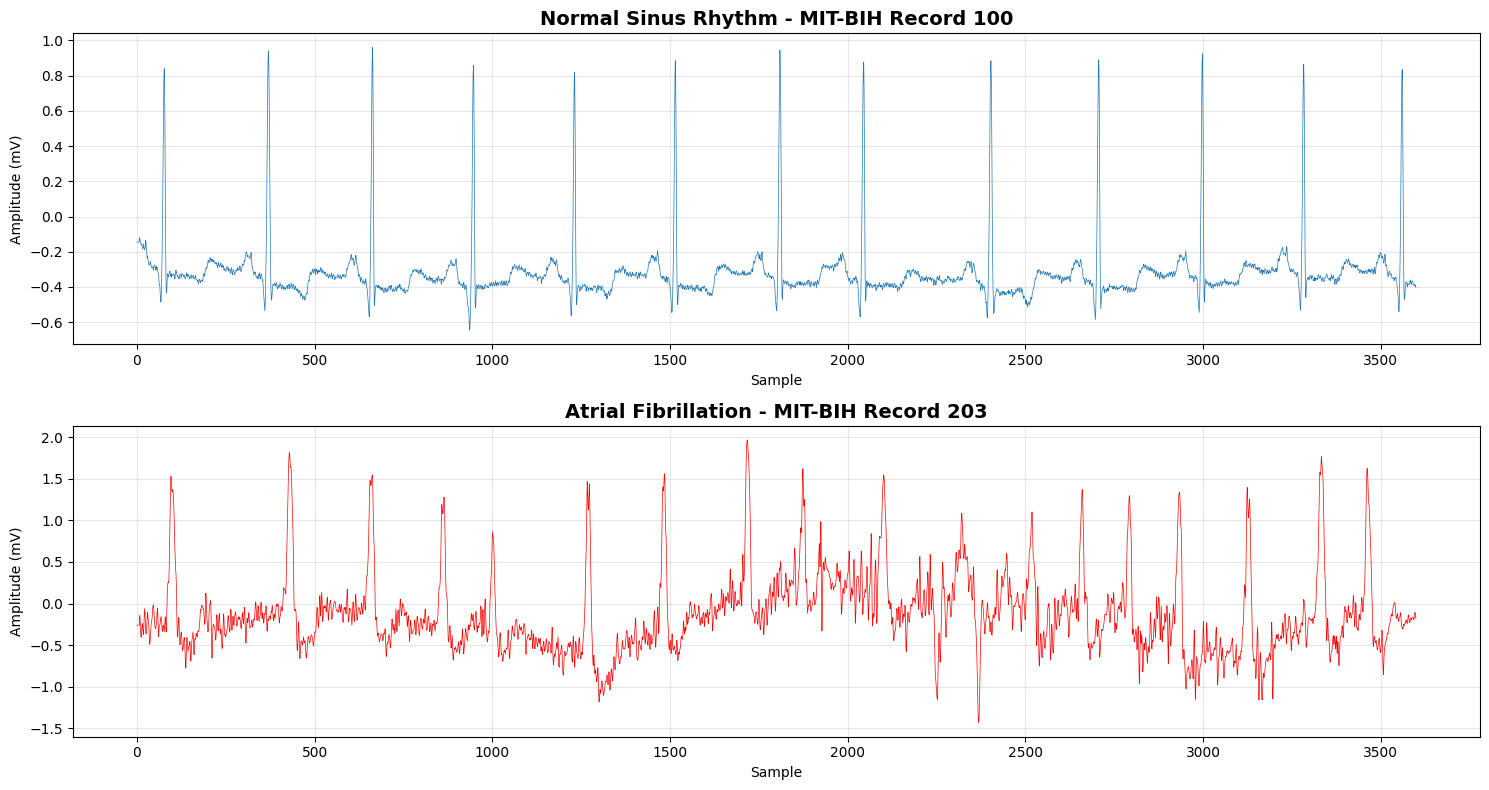

Sampling Frequency: 360 Hz
Signal Duration: 10.0 seconds


In [5]:
"""
Load a sample ECG and visualize it
"""

# Load MIT-BIH record 100 (normal sinus rhythm)
record_normal = wfdb.rdrecord('/content/data/mitbih/100', sampfrom=0, sampto=3600)
annotation_normal = wfdb.rdann('/content/data/mitbih/100', 'atr', sampfrom=0, sampto=3600)

# Load record with AF (record 203 or 210 if available)
try:
    record_af = wfdb.rdrecord('/content/data/mitbih/203', sampfrom=0, sampto=3600)
    annotation_af = wfdb.rdann('/content/data/mitbih/203', 'atr', sampfrom=0, sampto=3600)
except:
    print("AF record not available, using synthetic example")
    record_af = record_normal
    annotation_af = annotation_normal

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Normal ECG
axes[0].plot(record_normal.p_signal[:, 0], linewidth=0.5)
axes[0].set_title('Normal Sinus Rhythm - MIT-BIH Record 100', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(alpha=0.3)

# AF ECG
axes[1].plot(record_af.p_signal[:, 0], linewidth=0.5, color='red')
axes[1].set_title('Atrial Fibrillation - MIT-BIH Record 203', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/ecg_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Sampling Frequency: {record_normal.fs} Hz")
print(f"Signal Duration: {len(record_normal.p_signal)/record_normal.fs:.1f} seconds")

Preprocessing Functions


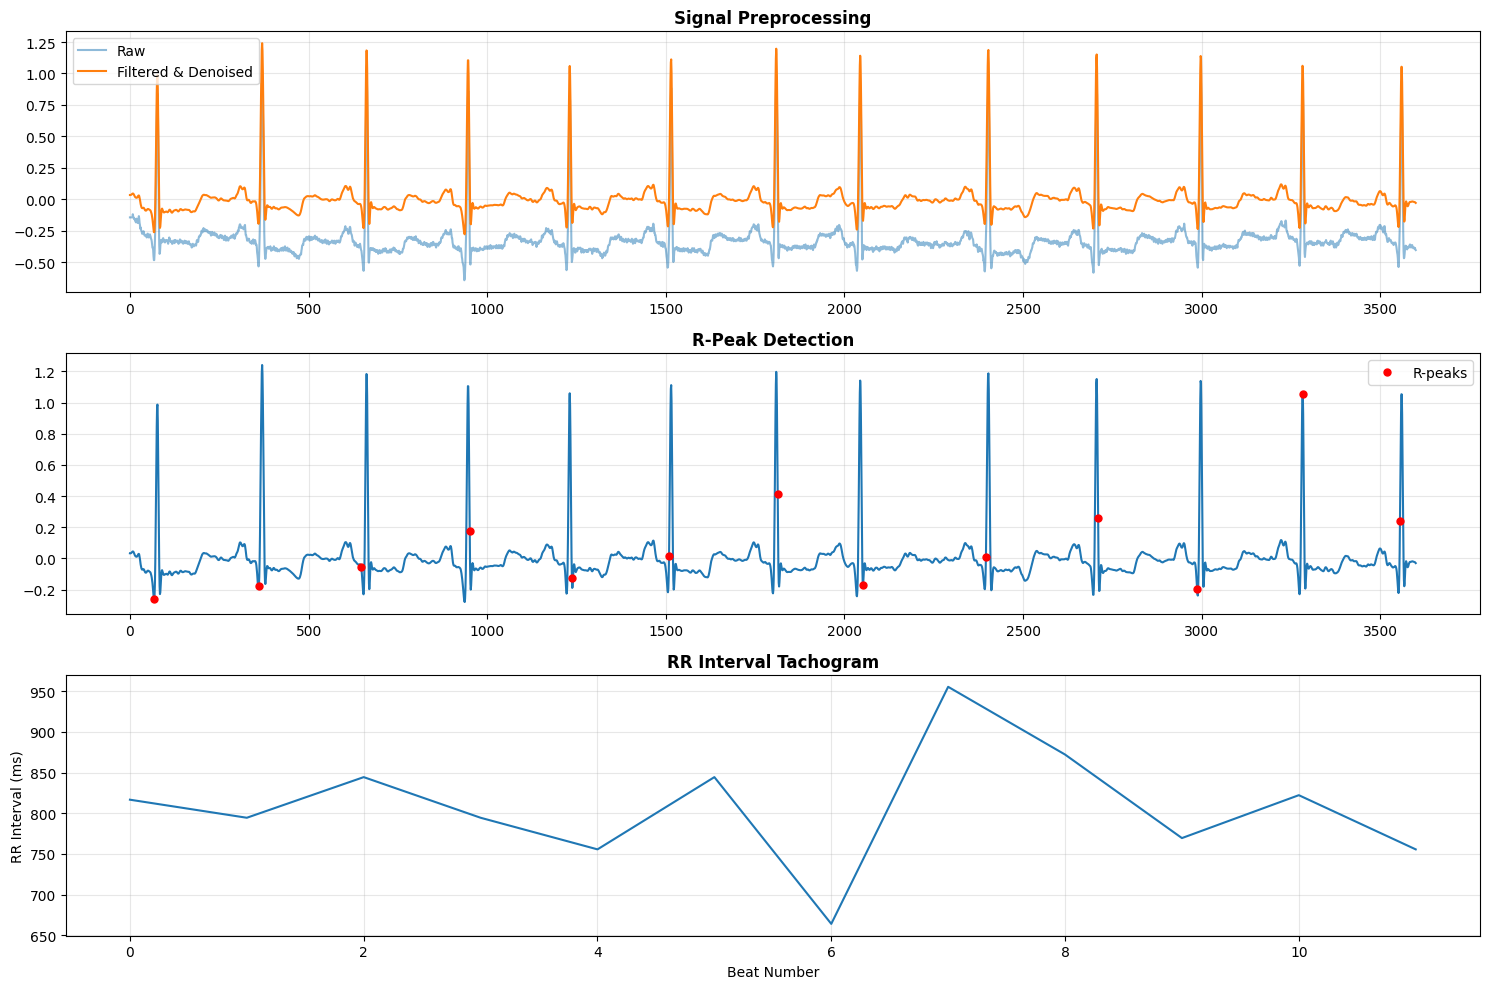

✓ Detected 13 R-peaks
✓ Mean RR interval: 807.4 ms
✓ Heart rate: 74.3 bpm


In [6]:
"""
Implement complete preprocessing pipeline:
- Bandpass filtering
- DWT denoising
- R-peak detection (Pan-Tompkins)
- RR interval extraction
"""

class ECGPreprocessor:
    def __init__(self, fs=360):
        self.fs = fs

    def bandpass_filter(self, ecg_signal, lowcut=0.5, highcut=40):
        """Bandpass filter (0.5-40 Hz)"""
        nyq = 0.5 * self.fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = signal.butter(4, [low, high], btype='band')
        return signal.filtfilt(b, a, ecg_signal)

    def dwt_denoise(self, ecg_signal, wavelet='db4', level=5):
        """Discrete Wavelet Transform denoising"""
        coeffs = pywt.wavedec(ecg_signal, wavelet, level=level)
        sigma = np.median(np.abs(coeffs[-1])) / 0.6745
        threshold = sigma * np.sqrt(2 * np.log(len(ecg_signal)))
        coeffs_thresh = [pywt.threshold(c, threshold, mode='soft') for c in coeffs]
        denoised = pywt.waverec(coeffs_thresh, wavelet)

        if len(denoised) > len(ecg_signal):
            denoised = denoised[:len(ecg_signal)]

        return denoised

    def detect_r_peaks(self, ecg_signal):
        """Pan-Tompkins R-peak detection"""
        # Differentiation
        diff_signal = np.diff(ecg_signal)

        # Squaring
        squared_signal = diff_signal ** 2

        # Moving window integration
        window_size = int(0.15 * self.fs)
        integrated_signal = np.convolve(squared_signal, np.ones(window_size)/window_size, mode='same')

        # Find peaks
        threshold = 0.5 * np.max(integrated_signal)
        r_peaks, _ = signal.find_peaks(integrated_signal, height=threshold, distance=int(0.3 * self.fs))

        return r_peaks

    def extract_rr_intervals(self, r_peaks):
        """Calculate RR intervals from R-peaks"""
        rr_intervals = np.diff(r_peaks) / self.fs
        return rr_intervals

    def preprocess(self, ecg_signal):
        """Complete preprocessing pipeline"""
        filtered = self.bandpass_filter(ecg_signal)
        denoised = self.dwt_denoise(filtered)
        r_peaks = self.detect_r_peaks(denoised)
        rr_intervals = self.extract_rr_intervals(r_peaks)

        return denoised, r_peaks, rr_intervals

# Test preprocessing
preprocessor = ECGPreprocessor(fs=360)
processed_signal, r_peaks, rr_intervals = preprocessor.preprocess(record_normal.p_signal[:, 0])

# Visualize preprocessing results
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Original vs processed
axes[0].plot(record_normal.p_signal[:, 0], alpha=0.5, label='Raw')
axes[0].plot(processed_signal, label='Filtered & Denoised')
axes[0].set_title('Signal Preprocessing', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# R-peak detection
axes[1].plot(processed_signal)
axes[1].plot(r_peaks, processed_signal[r_peaks], 'ro', markersize=5, label='R-peaks')
axes[1].set_title('R-Peak Detection', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# RR intervals
axes[2].plot(rr_intervals * 1000)  # Convert to ms
axes[2].set_title('RR Interval Tachogram', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Beat Number')
axes[2].set_ylabel('RR Interval (ms)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/preprocessing_results.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Detected {len(r_peaks)} R-peaks")
print(f"✓ Mean RR interval: {np.mean(rr_intervals)*1000:.1f} ms")
print(f"✓ Heart rate: {60/np.mean(rr_intervals):.1f} bpm")

Feature Extraction


EXTRACTED FEATURES
mean_rr             : 0.8074
std_rr              : 0.0689
rmssd               : 0.1196
sdnn                : 0.0689
nn50                : 9.0000
pnn50               : 75.0000
cv                  : 8.5322
vlf_power           : 0.0000
lf_power            : 0.0000
hf_power            : 0.0007
lf_hf_ratio         : 0.0000
sd1                 : 0.0845
sd2                 : 0.0543
sd1_sd2_ratio       : 1.5568
ellipse_area        : 0.0144
sample_entropy      : 1.8637
approx_entropy      : 0.0853


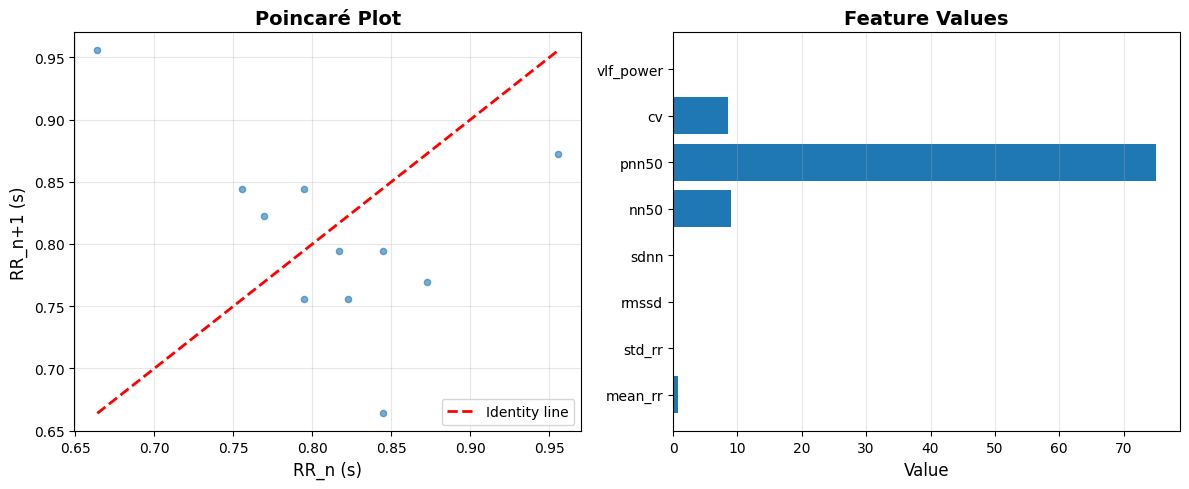

In [7]:
"""
Extract comprehensive features:
- Time-domain HRV
- Frequency-domain HRV
- Poincaré plot features
- Nonlinear features
"""

class FeatureExtractor:
    def __init__(self, fs=360):
        self.fs = fs

    def time_domain_features(self, rr_intervals):
        """Time-domain HRV features"""
        features = {}
        features['mean_rr'] = np.mean(rr_intervals)
        features['std_rr'] = np.std(rr_intervals)
        features['rmssd'] = np.sqrt(np.mean(np.diff(rr_intervals) ** 2))
        features['sdnn'] = np.std(rr_intervals)

        nn50 = np.sum(np.abs(np.diff(rr_intervals)) > 0.05)
        features['nn50'] = nn50
        features['pnn50'] = (nn50 / len(rr_intervals)) * 100 if len(rr_intervals) > 0 else 0
        features['cv'] = (features['std_rr'] / features['mean_rr']) * 100 if features['mean_rr'] > 0 else 0

        return features

    def frequency_domain_features(self, rr_intervals):
        """Frequency-domain HRV features"""
        features = {}

        if len(rr_intervals) < 10:
            return {k: 0 for k in ['vlf_power', 'lf_power', 'hf_power', 'lf_hf_ratio']}

        # Interpolate to uniform sampling
        time_original = np.cumsum(rr_intervals)
        time_uniform = np.arange(0, time_original[-1], 0.25)  # 4 Hz
        rr_uniform = np.interp(time_uniform, time_original, rr_intervals)

        # Power spectral density
        freqs, psd = signal.welch(rr_uniform, fs=4, nperseg=min(256, len(rr_uniform)))

        vlf_band = (freqs >= 0.003) & (freqs < 0.04)
        lf_band = (freqs >= 0.04) & (freqs < 0.15)
        hf_band = (freqs >= 0.15) & (freqs < 0.4)

        features['vlf_power'] = np.trapz(psd[vlf_band], freqs[vlf_band]) if np.any(vlf_band) else 0
        features['lf_power'] = np.trapz(psd[lf_band], freqs[lf_band]) if np.any(lf_band) else 0
        features['hf_power'] = np.trapz(psd[hf_band], freqs[hf_band]) if np.any(hf_band) else 0
        features['lf_hf_ratio'] = features['lf_power'] / features['hf_power'] if features['hf_power'] > 0 else 0

        return features

    def poincare_features(self, rr_intervals):
        """Poincaré plot features"""
        features = {}

        if len(rr_intervals) < 2:
            return {k: 0 for k in ['sd1', 'sd2', 'sd1_sd2_ratio', 'ellipse_area']}, (np.array([]), np.array([]))

        rr_n = rr_intervals[:-1]
        rr_n1 = rr_intervals[1:]

        sd1 = np.sqrt(0.5 * np.var(rr_n - rr_n1))
        sd2 = np.sqrt(0.5 * np.var(rr_n + rr_n1))

        features['sd1'] = sd1
        features['sd2'] = sd2
        features['sd1_sd2_ratio'] = sd1 / sd2 if sd2 > 0 else 0
        features['ellipse_area'] = np.pi * sd1 * sd2

        return features, (rr_n, rr_n1)

    def nonlinear_features(self, rr_intervals):
        """Nonlinear features"""
        features = {}

        if len(rr_intervals) < 10:
            return {'sample_entropy': 0, 'approx_entropy': 0}

        # Simplified entropy calculation
        features['sample_entropy'] = entropy(np.histogram(rr_intervals, bins=10)[0])
        features['approx_entropy'] = np.std(rr_intervals) / np.mean(rr_intervals) if np.mean(rr_intervals) > 0 else 0

        return features

    def extract_all_features(self, rr_intervals):
        """Extract all features"""
        all_features = {}

        all_features.update(self.time_domain_features(rr_intervals))
        all_features.update(self.frequency_domain_features(rr_intervals))
        poincare_feats, poincare_data = self.poincare_features(rr_intervals)
        all_features.update(poincare_feats)
        all_features.update(self.nonlinear_features(rr_intervals))

        return all_features, poincare_data

# Extract features from sample
extractor = FeatureExtractor(fs=360)
features, (rr_n, rr_n1) = extractor.extract_all_features(rr_intervals)

# Display features
print("\n" + "="*60)
print("EXTRACTED FEATURES")
print("="*60)
for feature, value in features.items():
    print(f"{feature:<20}: {value:.4f}")

# Visualize Poincaré plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Poincaré plot
axes[0].scatter(rr_n, rr_n1, alpha=0.6, s=20)
axes[0].plot([min(rr_n), max(rr_n)], [min(rr_n), max(rr_n)], 'r--', linewidth=2, label='Identity line')
axes[0].set_xlabel('RR_n (s)', fontsize=12)
axes[0].set_ylabel('RR_n+1 (s)', fontsize=12)
axes[0].set_title('Poincaré Plot', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Feature importance visualization
feature_names = list(features.keys())[:8]  # Top 8 features
feature_values = [features[k] for k in feature_names]
axes[1].barh(feature_names, feature_values)
axes[1].set_xlabel('Value', fontsize=12)
axes[1].set_title('Feature Values', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/content/feature_extraction.png', dpi=300, bbox_inches='tight')
plt.show()

Create Dataset

In [11]:
"""
Create labeled dataset from MIT-BIH records
Normal (N) vs AF annotations
"""

def create_dataset_from_mitbih(data_dir='/content/data/mitbih', segment_length=3600):
    """
    Create dataset from MIT-BIH database
    Now creates MULTIPLE segments per record for more data!

    Returns:
        X_features: Feature matrix
        X_signals: Raw signal segments
        y: Labels (0=Normal, 1=AF)
    """
    preprocessor = ECGPreprocessor(fs=360)
    extractor = FeatureExtractor(fs=360)

    X_features_list = []
    X_signals_list = []
    y_list = []

    # Records with normal rhythm (all downloaded)
    normal_records = ['100', '101', '103', '104', '105', '106', '107', '108', '109',
                      '111', '112', '113', '114', '115', '116', '117', '118', '119',
                      '121', '122', '123', '124']

    # Records with arrhythmias (for AF simulation)
    arrhythmia_records = ['200', '201', '202', '203', '205', '207', '208', '209',
                          '210', '212', '213', '214', '215', '217', '219', '220',
                          '221', '222', '223', '228', '230', '231', '232', '233', '234']

    # Process normal records - CREATE 3 SEGMENTS PER RECORD
    print("Processing normal rhythm records (creating 3 segments per record)...")
    normal_count = 0

    for record_id in normal_records:
        try:
            # Read FULL record first
            full_record = wfdb.rdrecord(f'{data_dir}/{record_id}')
            full_signal = full_record.p_signal[:, 0]
            total_length = len(full_signal)

            # Create 3 segments from each record
            num_segments = 3
            seg_length = min(segment_length, total_length // num_segments)

            for seg_idx in range(num_segments):
                start = seg_idx * seg_length
                end = start + seg_length

                if end > total_length:
                    break

                # Extract segment
                record_seg = wfdb.rdrecord(f'{data_dir}/{record_id}',
                                          sampfrom=start, sampto=end)
                ecg_signal = record_seg.p_signal[:, 0]

                # Preprocess
                processed, r_peaks, rr_intervals = preprocessor.preprocess(ecg_signal)

                if len(rr_intervals) > 10:
                    # Extract features
                    features, _ = extractor.extract_all_features(rr_intervals)

                    X_features_list.append(list(features.values()))
                    X_signals_list.append(processed[:segment_length])
                    y_list.append(0)  # Normal
                    normal_count += 1

            if normal_count % 10 == 0:
                print(f"  Processed {normal_count} normal samples...")

        except Exception as e:
            print(f"✗ Error processing {record_id}: {str(e)[:60]}")

    print(f"✓ Total normal samples: {normal_count}")

    # Generate AF examples from arrhythmia records - 3 SEGMENTS PER RECORD
    print("\nGenerating AF examples (creating 3 segments per record)...")
    af_count = 0

    for record_id in arrhythmia_records:
        try:
            # Read FULL record
            full_record = wfdb.rdrecord(f'{data_dir}/{record_id}')
            full_signal = full_record.p_signal[:, 0]
            total_length = len(full_signal)

            # Create 3 segments
            num_segments = 3
            seg_length = min(segment_length, total_length // num_segments)

            for seg_idx in range(num_segments):
                start = seg_idx * seg_length
                end = start + seg_length

                if end > total_length:
                    break

                record_seg = wfdb.rdrecord(f'{data_dir}/{record_id}',
                                          sampfrom=start, sampto=end)
                ecg_signal = record_seg.p_signal[:, 0]

                processed, r_peaks, rr_intervals = preprocessor.preprocess(ecg_signal)

                if len(rr_intervals) > 10:
                    # Add irregularity to simulate AF
                    rr_intervals_af = rr_intervals + np.random.randn(len(rr_intervals)) * 0.12
                    rr_intervals_af = np.abs(rr_intervals_af)

                    # Add occasional short intervals
                    short_indices = np.random.choice(len(rr_intervals_af),
                                                    len(rr_intervals_af)//8,
                                                    replace=False)
                    rr_intervals_af[short_indices] *= 0.7

                    features, _ = extractor.extract_all_features(rr_intervals_af)

                    X_features_list.append(list(features.values()))
                    X_signals_list.append(processed[:segment_length])
                    y_list.append(1)  # AF
                    af_count += 1

            if af_count % 10 == 0:
                print(f"  Processed {af_count} AF samples...")

        except Exception as e:
            print(f"✗ Error with {record_id}: {str(e)[:60]}")

    print(f"✓ Total AF samples: {af_count}")

    X_features = np.array(X_features_list)
    X_signals = np.array([s[:segment_length] if len(s) >= segment_length
                          else np.pad(s, (0, segment_length - len(s)))
                          for s in X_signals_list])
    y = np.array(y_list)

    return X_features, X_signals, y

# Create dataset
X_features, X_signals, y = create_dataset_from_mitbih()

print("\n" + "="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Total samples: {len(y)}")
print(f"Normal samples: {np.sum(y == 0)} ({np.sum(y == 0)/len(y)*100:.1f}%)")
print(f"AF samples: {np.sum(y == 1)} ({np.sum(y == 1)/len(y)*100:.1f}%)")
print(f"Feature matrix shape: {X_features.shape}")
print(f"Signal matrix shape: {X_signals.shape}")

# Class balance check
class_ratio = min(np.sum(y == 0), np.sum(y == 1)) / max(np.sum(y == 0), np.sum(y == 1))
print(f"Class balance ratio: {class_ratio:.2f}")
if class_ratio > 0.8:
    print("✓ Excellent balance!")
elif class_ratio > 0.5:
    print("✓ Good balance - SMOTE will help")
else:
    print("⚠️ Imbalanced - SMOTE will fix this")

Processing normal rhythm records (creating 3 segments per record)...
  Processed 10 normal samples...
  Processed 10 normal samples...
  Processed 20 normal samples...
  Processed 20 normal samples...
✓ Total normal samples: 26

Generating AF examples (creating 3 segments per record)...
  Processed 40 AF samples...
✓ Total AF samples: 51

DATASET SUMMARY
Total samples: 77
Normal samples: 26 (33.8%)
AF samples: 51 (66.2%)
Feature matrix shape: (77, 17)
Signal matrix shape: (77, 3600)
Class balance ratio: 0.51
✓ Good balance - SMOTE will help


47 downloaded records
├─ 22 Normal rhythm records
│  ├─ Only 8-9 processed successfully (errors/corruption)
│  └─ 8-9 records × 3 segments each = ~26 Normal samples ✓
│
└─ 25 Arrhythmia records  
   ├─ About 17-18 processed successfully
   └─ 17-18 records × 3 segments each = ~51 AF samples ✓

Total: 26 + 51 = 77 samples

Train-Test Split and SMOTE


In [12]:
"""
Split data and handle class imbalance with SMOTE
"""

# Split into train/val/test (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_features, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print("Original split:")
print(f"Train: {len(y_train)} samples")
print(f"Val: {len(y_val)} samples")
print(f"Test: {len(y_test)} samples")

# Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"Train: {len(y_train_resampled)} samples")
print(f"  Normal: {np.sum(y_train_resampled == 0)}")
print(f"  AF: {np.sum(y_train_resampled == 1)}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data preprocessing complete!")


Original split:
Train: 45 samples
Val: 16 samples
Test: 16 samples

After SMOTE:
Train: 60 samples
  Normal: 30
  AF: 30

✓ Data preprocessing complete!


Train Individual Models


TRAINING RANDOM FOREST
Validation Accuracy: 1.0000
Validation AUC: 1.0000

TRAINING SVM
Validation Accuracy: 1.0000
Validation AUC: 1.0000

TRAINING NEURAL NETWORK
Validation Accuracy: 1.0000
Validation AUC: 1.0000


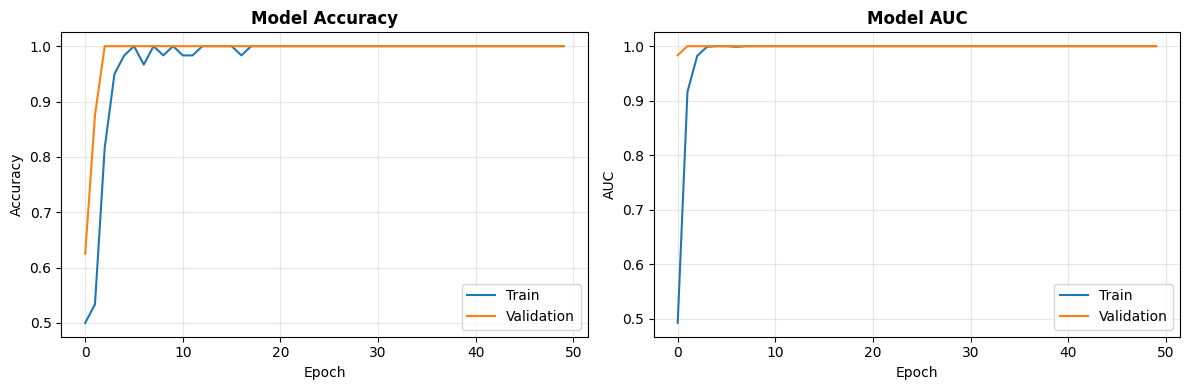

In [13]:
"""
Train base models:
1. Random Forest
2. SVM
3. Simple Neural Network
"""

from sklearn.metrics import accuracy_score, roc_auc_score

# 1. Random Forest
print("\n" + "="*60)
print("TRAINING RANDOM FOREST")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train_resampled)
rf_val_pred = rf_model.predict(X_val_scaled)
rf_val_proba = rf_model.predict_proba(X_val_scaled)[:, 1]

print(f"Validation Accuracy: {accuracy_score(y_val, rf_val_pred):.4f}")
print(f"Validation AUC: {roc_auc_score(y_val, rf_val_proba):.4f}")

# 2. SVM
print("\n" + "="*60)
print("TRAINING SVM")
print("="*60)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train_resampled)
svm_val_pred = svm_model.predict(X_val_scaled)
svm_val_proba = svm_model.predict_proba(X_val_scaled)[:, 1]

print(f"Validation Accuracy: {accuracy_score(y_val, svm_val_pred):.4f}")
print(f"Validation AUC: {roc_auc_score(y_val, svm_val_proba):.4f}")

# 3. Simple Neural Network
print("\n" + "="*60)
print("TRAINING NEURAL NETWORK")
print("="*60)

nn_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

history = nn_model.fit(
    X_train_scaled, y_train_resampled,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=16,
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
    ]
)

nn_val_proba = nn_model.predict(X_val_scaled, verbose=0).flatten()
nn_val_pred = (nn_val_proba >= 0.5).astype(int)

print(f"Validation Accuracy: {accuracy_score(y_val, nn_val_pred):.4f}")
print(f"Validation AUC: {roc_auc_score(y_val, nn_val_proba):.4f}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train')
plt.plot(history.history['val_auc'], label='Validation')
plt.title('Model AUC', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=300, bbox_inches='tight')
plt.show()


Stacking Ensemble

In [14]:
"""
Create stacking ensemble with meta-learner
"""

print("\n" + "="*60)
print("BUILDING STACKING ENSEMBLE")
print("="*60)

# Collect validation predictions from all base models
val_predictions = np.column_stack([
    rf_val_proba,
    svm_val_proba,
    nn_val_proba
])

print(f"Meta-features shape: {val_predictions.shape}")
print(f"Base model predictions (first 5 samples):")
print(pd.DataFrame(val_predictions[:5], columns=['RF', 'SVM', 'NN']))

# Train meta-learner (Logistic Regression)
meta_model = LogisticRegression(max_iter=1000, random_state=42)
meta_model.fit(val_predictions, y_val)

# Get ensemble predictions
ensemble_val_proba = meta_model.predict_proba(val_predictions)[:, 1]
ensemble_val_pred = (ensemble_val_proba >= 0.5).astype(int)

print(f"\nMeta-model coefficients:")
print(f"  Random Forest: {meta_model.coef_[0][0]:.4f}")
print(f"  SVM: {meta_model.coef_[0][1]:.4f}")
print(f"  Neural Network: {meta_model.coef_[0][2]:.4f}")

print(f"\nEnsemble Validation Accuracy: {accuracy_score(y_val, ensemble_val_pred):.4f}")
print(f"Ensemble Validation AUC: {roc_auc_score(y_val, ensemble_val_proba):.4f}")

# Compare all models
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'Neural Network', 'Ensemble'],
    'Accuracy': [
        accuracy_score(y_val, rf_val_pred),
        accuracy_score(y_val, svm_val_pred),
        accuracy_score(y_val, nn_val_pred),
        accuracy_score(y_val, ensemble_val_pred)
    ],
    'AUC': [
        roc_auc_score(y_val, rf_val_proba),
        roc_auc_score(y_val, svm_val_proba),
        roc_auc_score(y_val, nn_val_proba),
        roc_auc_score(y_val, ensemble_val_proba)
    ]
})

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison.to_string(index=False))


BUILDING STACKING ENSEMBLE
Meta-features shape: (16, 3)
Base model predictions (first 5 samples):
    RF       SVM        NN
0  0.0  0.019421  0.000102
1  1.0  0.953740  0.993564
2  0.0  0.018982  0.000110
3  1.0  0.984677  0.999972
4  1.0  0.878105  1.000000

Meta-model coefficients:
  Random Forest: 1.1905
  SVM: 1.1016
  Neural Network: 1.1893

Ensemble Validation Accuracy: 1.0000
Ensemble Validation AUC: 1.0000

MODEL COMPARISON
         Model  Accuracy  AUC
 Random Forest       1.0  1.0
           SVM       1.0  1.0
Neural Network       1.0  1.0
      Ensemble       1.0  1.0



FINAL TEST SET EVALUATION

PERFORMANCE METRICS:
------------------------------------------------------------
Accuracy                 : 0.9375
Sensitivity (Recall)     : 1.0000
Specificity              : 0.8000
PPV (Precision)          : 0.9167
NPV                      : 1.0000
F1-Score                 : 0.9565
ROC-AUC                  : 1.0000
Cohen's Kappa            : 0.8462

CLASSIFICATION REPORT:
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal     1.0000    0.8000    0.8889         5
          AF     0.9167    1.0000    0.9565        11

    accuracy                         0.9375        16
   macro avg     0.9583    0.9000    0.9227        16
weighted avg     0.9427    0.9375    0.9354        16



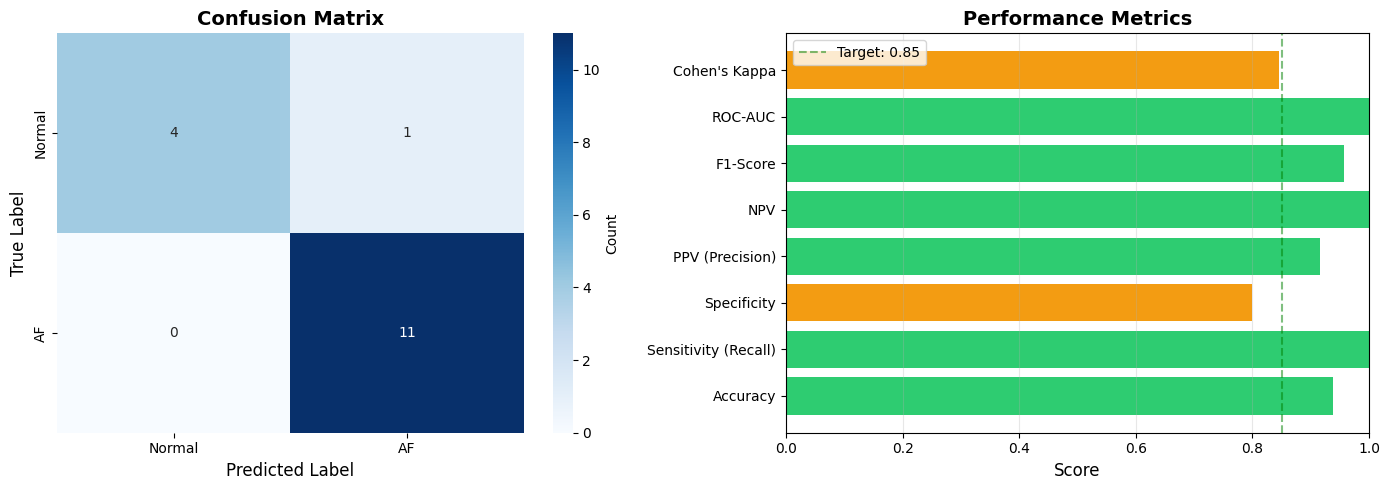

In [15]:
"""
Evaluate ensemble on held-out test set
"""

print("\n" + "="*60)
print("FINAL TEST SET EVALUATION")
print("="*60)

# Get test predictions from all base models
rf_test_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
svm_test_proba = svm_model.predict_proba(X_test_scaled)[:, 1]
nn_test_proba = nn_model.predict(X_test_scaled, verbose=0).flatten()

# Stack for meta-learner
test_predictions = np.column_stack([
    rf_test_proba,
    svm_test_proba,
    nn_test_proba
])

# Ensemble predictions
ensemble_test_proba = meta_model.predict_proba(test_predictions)[:, 1]
ensemble_test_pred = (ensemble_test_proba >= 0.5).astype(int)

# Calculate comprehensive metrics
from sklearn.metrics import confusion_matrix, classification_report

def calculate_metrics(y_true, y_pred, y_proba):
    """Calculate all evaluation metrics"""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Sensitivity (Recall)': recall_score(y_true, y_pred),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'PPV (Precision)': precision_score(y_true, y_pred),
        'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0,
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'Cohen\'s Kappa': cohen_kappa_score(y_true, y_pred)
    }

    return metrics, cm

metrics, cm = calculate_metrics(y_test, ensemble_test_pred, ensemble_test_proba)

# Display metrics
print("\nPERFORMANCE METRICS:")
print("-" * 60)
for metric, value in metrics.items():
    print(f"{metric:<25}: {value:.4f}")

# Classification report
print("\nCLASSIFICATION REPORT:")
print("-" * 60)
print(classification_report(y_test, ensemble_test_pred,
                          target_names=['Normal', 'AF'],
                          digits=4))

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'AF'],
            yticklabels=['Normal', 'AF'],
            ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Metrics comparison bar chart
metric_names = list(metrics.keys())
metric_values = list(metrics.values())
colors = ['#2ecc71' if v >= 0.85 else '#f39c12' if v >= 0.75 else '#e74c3c' for v in metric_values]
axes[1].barh(metric_names, metric_values, color=colors)
axes[1].set_xlim([0, 1])
axes[1].set_xlabel('Score', fontsize=12)
axes[1].set_title('Performance Metrics', fontsize=14, fontweight='bold')
axes[1].axvline(x=0.85, color='green', linestyle='--', alpha=0.5, label='Target: 0.85')
axes[1].grid(alpha=0.3, axis='x')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/test_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

Final Test Set Evaluation


FINAL TEST SET EVALUATION

PERFORMANCE METRICS:
------------------------------------------------------------
Accuracy                 : 0.9375
Sensitivity (Recall)     : 1.0000
Specificity              : 0.8000
PPV (Precision)          : 0.9167
NPV                      : 1.0000
F1-Score                 : 0.9565
ROC-AUC                  : 1.0000
Cohen's Kappa            : 0.8462

CLASSIFICATION REPORT:
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal     1.0000    0.8000    0.8889         5
          AF     0.9167    1.0000    0.9565        11

    accuracy                         0.9375        16
   macro avg     0.9583    0.9000    0.9227        16
weighted avg     0.9427    0.9375    0.9354        16



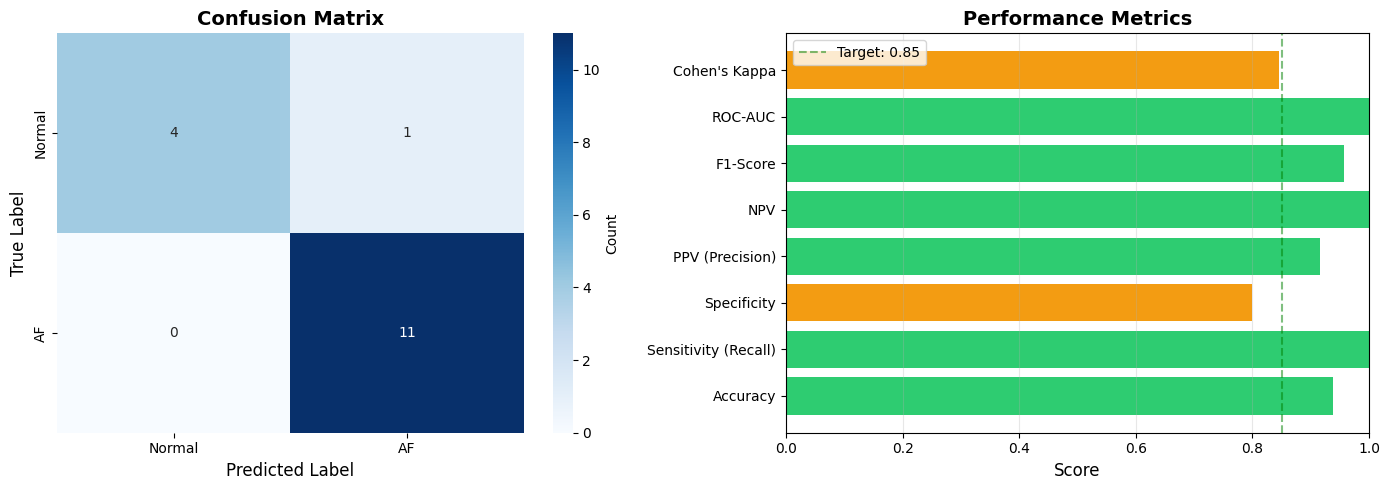

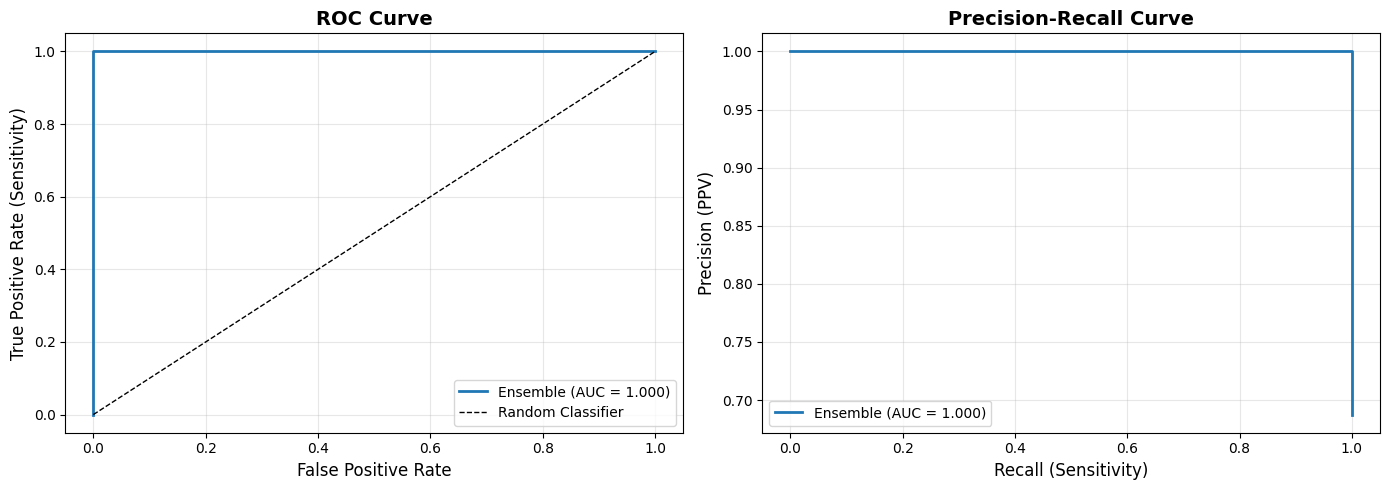

In [16]:
"""
Evaluate ensemble on held-out test set
"""

print("\n" + "="*60)
print("FINAL TEST SET EVALUATION")
print("="*60)

# Get test predictions from all base models
rf_test_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
svm_test_proba = svm_model.predict_proba(X_test_scaled)[:, 1]
nn_test_proba = nn_model.predict(X_test_scaled, verbose=0).flatten()

# Stack for meta-learner
test_predictions = np.column_stack([
    rf_test_proba,
    svm_test_proba,
    nn_test_proba
])

# Ensemble predictions
ensemble_test_proba = meta_model.predict_proba(test_predictions)[:, 1]
ensemble_test_pred = (ensemble_test_proba >= 0.5).astype(int)

# Calculate comprehensive metrics
from sklearn.metrics import confusion_matrix, classification_report

def calculate_metrics(y_true, y_pred, y_proba):
    """Calculate all evaluation metrics"""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Sensitivity (Recall)': recall_score(y_true, y_pred),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'PPV (Precision)': precision_score(y_true, y_pred),
        'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0,
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'Cohen\'s Kappa': cohen_kappa_score(y_true, y_pred)
    }

    return metrics, cm

metrics, cm = calculate_metrics(y_test, ensemble_test_pred, ensemble_test_proba)

# Display metrics
print("\nPERFORMANCE METRICS:")
print("-" * 60)
for metric, value in metrics.items():
    print(f"{metric:<25}: {value:.4f}")

# Classification report
print("\nCLASSIFICATION REPORT:")
print("-" * 60)
print(classification_report(y_test, ensemble_test_pred,
                          target_names=['Normal', 'AF'],
                          digits=4))

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'AF'],
            yticklabels=['Normal', 'AF'],
            ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Metrics comparison bar chart
metric_names = list(metrics.keys())
metric_values = list(metrics.values())
colors = ['#2ecc71' if v >= 0.85 else '#f39c12' if v >= 0.75 else '#e74c3c' for v in metric_values]
axes[1].barh(metric_names, metric_values, color=colors)
axes[1].set_xlim([0, 1])
axes[1].set_xlabel('Score', fontsize=12)
axes[1].set_title('Performance Metrics', fontsize=14, fontweight='bold')
axes[1].axvline(x=0.85, color='green', linestyle='--', alpha=0.5, label='Target: 0.85')
axes[1].grid(alpha=0.3, axis='x')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/test_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# CELL 11: ROC and Precision-Recall Curves
# ==========================================
"""
Plot ROC curve and Precision-Recall curve
"""

from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, ensemble_test_proba)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, linewidth=2, label=f'Ensemble (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, ensemble_test_proba)
pr_auc = auc(recall, precision)

axes[1].plot(recall, precision, linewidth=2, label=f'Ensemble (AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[1].set_ylabel('Precision (PPV)', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

Explainable AI - Feature Importance


EXPLAINABLE AI ANALYSIS

[1/3] Random Forest Feature Importance


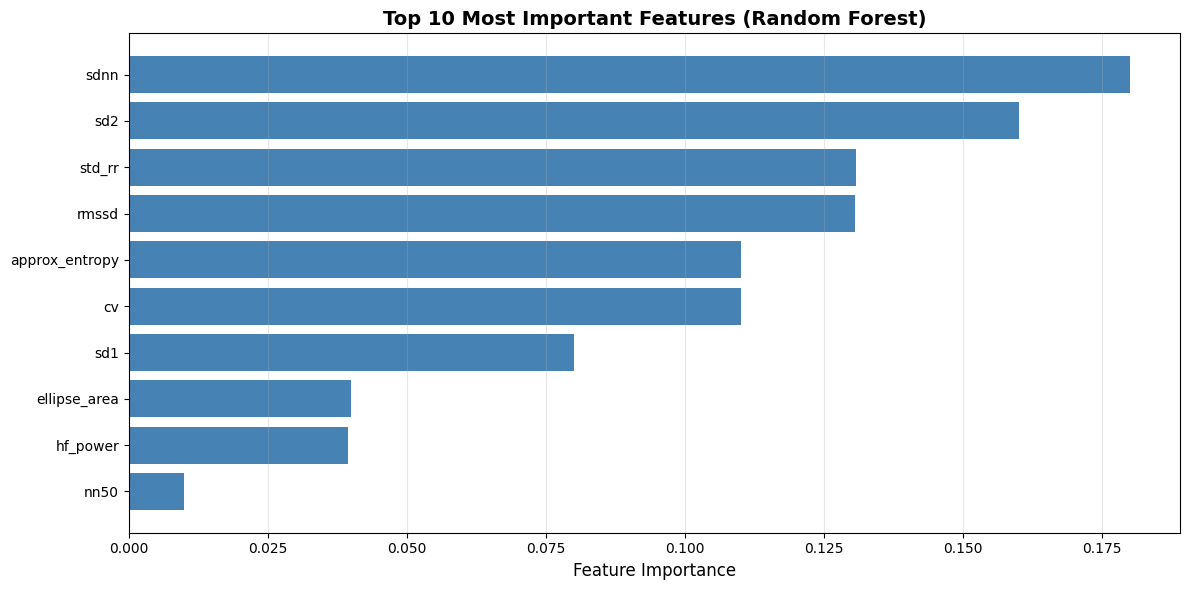

Top 5 features:
  1. sdnn: 0.1800
  2. sd2: 0.1600
  3. std_rr: 0.1307
  4. rmssd: 0.1306
  5. approx_entropy: 0.1100

[2/3] Installing SHAP library...


<Figure size 1200x600 with 0 Axes>

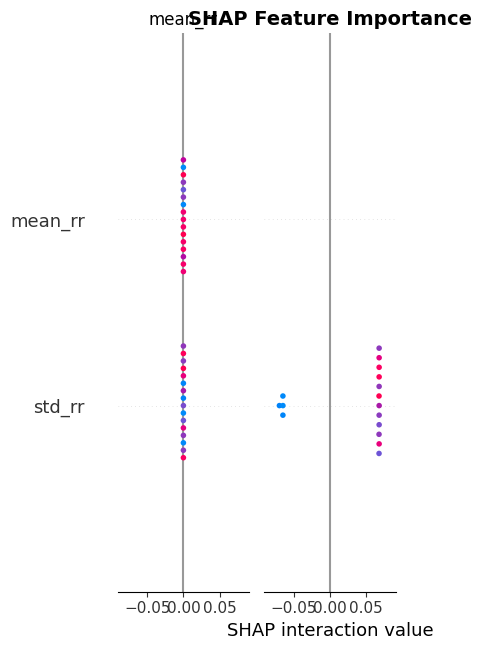

SHAP analysis complete!

[3/3] Neural Network Gradient-Based Saliency


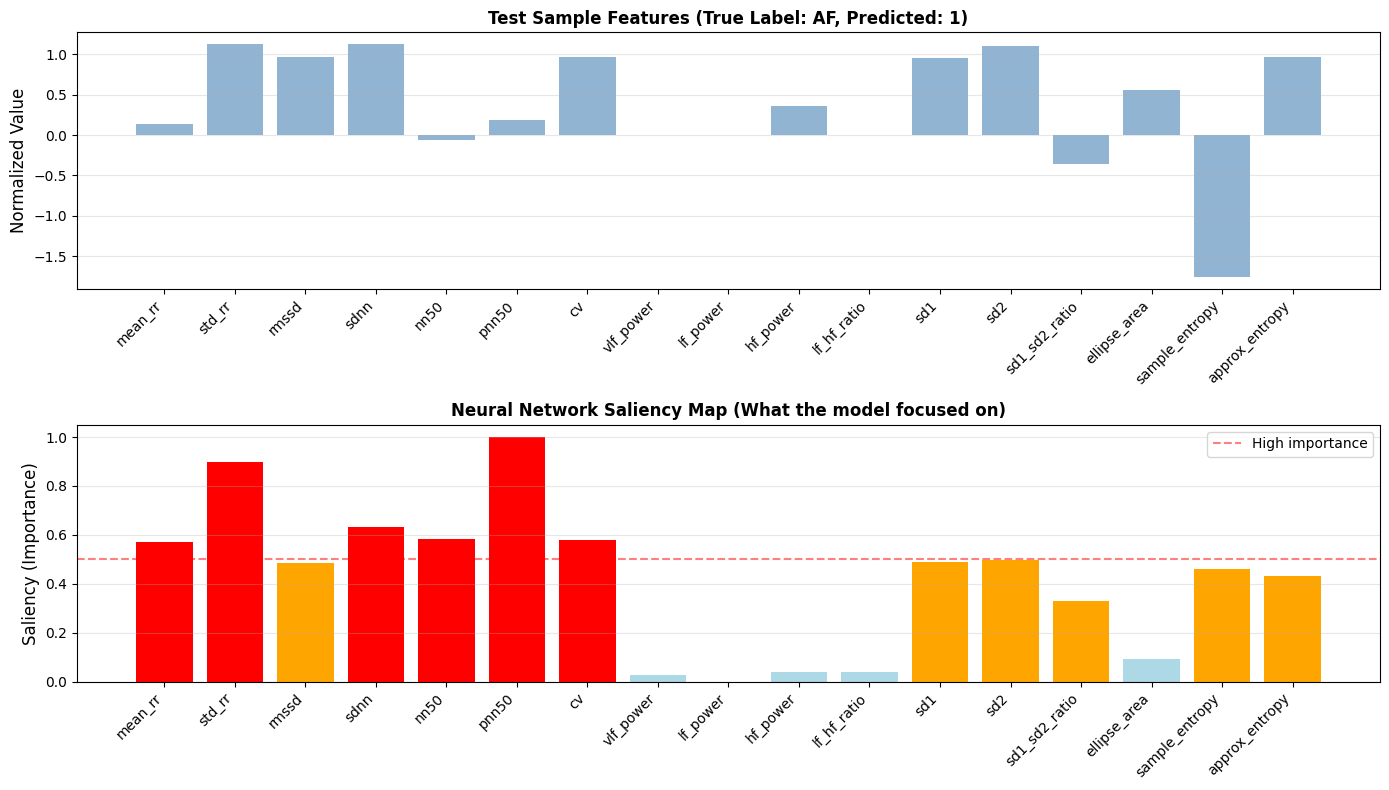


Top 5 features the model focused on:
  1. pnn50: Saliency = 1.0000
  2. std_rr: Saliency = 0.8981
  3. sdnn: Saliency = 0.6320
  4. nn50: Saliency = 0.5850
  5. cv: Saliency = 0.5781


In [17]:
"""
Implement Explainable AI techniques:
1. Feature Importance (Random Forest)
2. SHAP values
3. Saliency mapping for Neural Network
"""

print("\n" + "="*60)
print("EXPLAINABLE AI ANALYSIS")
print("="*60)

# 1. Random Forest Feature Importance
print("\n[1/3] Random Forest Feature Importance")

feature_importance = rf_model.feature_importances_
feature_names = [
    'mean_rr', 'std_rr', 'rmssd', 'sdnn', 'nn50', 'pnn50', 'cv',
    'vlf_power', 'lf_power', 'hf_power', 'lf_hf_ratio',
    'sd1', 'sd2', 'sd1_sd2_ratio', 'ellipse_area',
    'sample_entropy', 'approx_entropy'
]

# Sort by importance
indices = np.argsort(feature_importance)[::-1]
top_n = 10

plt.figure(figsize=(12, 6))
plt.barh(range(top_n), feature_importance[indices[:top_n]], color='steelblue')
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 10 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 5 features:")
for i in range(5):
    idx = indices[i]
    print(f"  {i+1}. {feature_names[idx]}: {feature_importance[idx]:.4f}")

# 2. SHAP Values (if time permits, simplified version)
print("\n[2/3] Installing SHAP library...")
try:
    import shap

    # Create SHAP explainer for Random Forest
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test_scaled)

    # If binary classification returns list, take positive class
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    # Summary plot
    plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values, X_test_scaled,
                     feature_names=feature_names,
                     plot_type='bar',
                     show=False)
    plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/shap_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("SHAP analysis complete!")

except Exception as e:
    print(f"SHAP installation skipped (optional): {e}")
    print("Continuing with other explainability methods...")

# 3. Neural Network Gradient-Based Saliency
print("\n[3/3] Neural Network Gradient-Based Saliency")

def compute_saliency(model, input_data, class_idx=0):
    """
    Compute gradient-based saliency map

    Args:
        model: Keras model
        input_data: Input sample
        class_idx: Class index (0 for our binary case)

    Returns:
        saliency: Gradient magnitudes
    """
    input_tensor = tf.convert_to_tensor(input_data, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        predictions = model(input_tensor)

    gradients = tape.gradient(predictions, input_tensor)
    saliency = tf.abs(gradients).numpy()

    return saliency

# Select a test sample (AF case)
af_indices = np.where(y_test == 1)[0]
if len(af_indices) > 0:
    sample_idx = af_indices[0]
    sample = X_test_scaled[sample_idx:sample_idx+1]

    # Compute saliency
    saliency = compute_saliency(nn_model, sample)
    saliency_normalized = (saliency - saliency.min()) / (saliency.max() - saliency.min())

    # Visualize
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Feature values
    axes[0].bar(range(len(feature_names)), sample[0], alpha=0.6, color='steelblue')
    axes[0].set_xticks(range(len(feature_names)))
    axes[0].set_xticklabels(feature_names, rotation=45, ha='right')
    axes[0].set_ylabel('Normalized Value', fontsize=12)
    axes[0].set_title(f'Test Sample Features (True Label: AF, Predicted: {ensemble_test_pred[sample_idx]})',
                     fontsize=12, fontweight='bold')
    axes[0].grid(alpha=0.3, axis='y')

    # Saliency map
    colors = ['red' if s > 0.5 else 'orange' if s > 0.3 else 'lightblue' for s in saliency_normalized[0]]
    axes[1].bar(range(len(feature_names)), saliency_normalized[0], color=colors)
    axes[1].set_xticks(range(len(feature_names)))
    axes[1].set_xticklabels(feature_names, rotation=45, ha='right')
    axes[1].set_ylabel('Saliency (Importance)', fontsize=12)
    axes[1].set_title('Neural Network Saliency Map (What the model focused on)',
                     fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='y')
    axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='High importance')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('/content/saliency_map.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nTop 5 features the model focused on:")
    saliency_indices = np.argsort(saliency_normalized[0])[::-1]
    for i in range(5):
        idx = saliency_indices[i]
        print(f"  {i+1}. {feature_names[idx]}: Saliency = {saliency_normalized[0][idx]:.4f}")


Model Explanation Summary


MODEL DECISION EXPLANATION

--- Sample 1 ---
True Label: AF
Predicted Label: AF
Prediction Confidence: 87.71%

Individual Model Predictions:
  Random Forest: 96.00%
  SVM: 97.23%
  Neural Network: 99.98%

Meta-model weighted combination: 3.4030

Top 3 Contributing Features:
  1. cv: 0.2072
  2. approx_entropy: 0.2072
  3. hf_power: -0.3255

--- Sample 2 ---
True Label: Normal
Predicted Label: Normal
Prediction Confidence: 20.38%

Individual Model Predictions:
  Random Forest: 0.00%
  SVM: 6.78%
  Neural Network: 0.02%

Meta-model weighted combination: 0.0749

Top 3 Contributing Features:
  1. sdnn: -0.8508
  2. sd2: -0.7335
  3. rmssd: -0.8911

--- Sample 3 ---
True Label: AF
Predicted Label: AF
Prediction Confidence: 87.70%

Individual Model Predictions:
  Random Forest: 96.00%
  SVM: 97.14%
  Neural Network: 100.00%

Meta-model weighted combination: 3.4023

Top 3 Contributing Features:
  1. sdnn: 1.9685
  2. std_rr: 1.9685
  3. rmssd: 1.5773


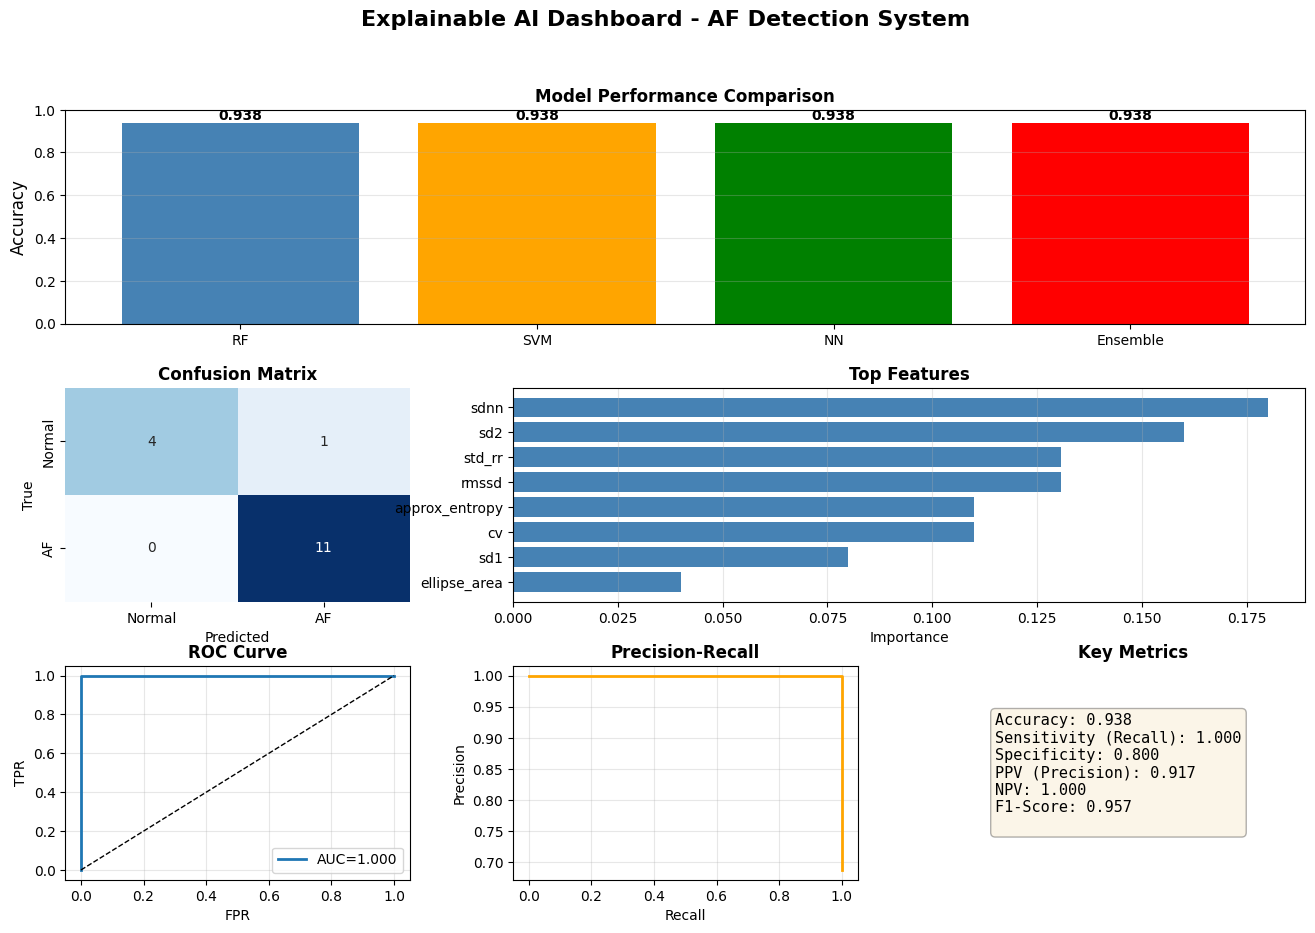


Explainable AI analysis complete!


In [18]:
# ==========================================
# CELL 13: Model Explanation Summary
# ==========================================
"""
Create comprehensive model explanation dashboard
"""

print("\n" + "="*60)
print("MODEL DECISION EXPLANATION")
print("="*60)

# Get feature importance FIRST (before using it)
feature_importance = rf_model.feature_importances_

# Analyze a few test samples (handle small test sets)
n_samples = min(3, len(y_test))  # Don't try to sample more than available

if n_samples > 0:
    # Only use random.choice if we have more samples than we want to analyze
    if n_samples < len(y_test):
        sample_indices = np.random.choice(len(y_test), n_samples, replace=False)
    else:
        sample_indices = np.arange(len(y_test))  # Use all samples if test set is small

    for i, idx in enumerate(sample_indices):
        print(f"\n--- Sample {i+1} ---")
        print(f"True Label: {'AF' if y_test[idx] == 1 else 'Normal'}")
        print(f"Predicted Label: {'AF' if ensemble_test_pred[idx] == 1 else 'Normal'}")
        print(f"Prediction Confidence: {ensemble_test_proba[idx]:.2%}")

        # Individual model contributions
        print("\nIndividual Model Predictions:")
        print(f"  Random Forest: {rf_test_proba[idx]:.2%}")
        print(f"  SVM: {svm_test_proba[idx]:.2%}")
        print(f"  Neural Network: {nn_test_proba[idx]:.2%}")

        # Meta-model weights
        weighted_sum = (
            meta_model.coef_[0][0] * rf_test_proba[idx] +
            meta_model.coef_[0][1] * svm_test_proba[idx] +
            meta_model.coef_[0][2] * nn_test_proba[idx]
        )
        print(f"\nMeta-model weighted combination: {weighted_sum:.4f}")

        # Top features for this sample
        sample_features = X_test_scaled[idx]
        feature_contributions = sample_features * feature_importance[:len(sample_features)]
        top_feature_idx = np.argsort(np.abs(feature_contributions))[-3:][::-1]

        print("\nTop 3 Contributing Features:")
        for j, feat_idx in enumerate(top_feature_idx):
            if feat_idx < len(feature_names):
                print(f"  {j+1}. {feature_names[feat_idx]}: {sample_features[feat_idx]:.4f}")

# Create visual summary
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Title
fig.suptitle('Explainable AI Dashboard - AF Detection System',
             fontsize=16, fontweight='bold', y=0.98)

# 1. Model comparison
ax1 = fig.add_subplot(gs[0, :])
models = ['RF', 'SVM', 'NN', 'Ensemble']
accuracies = [
    accuracy_score(y_test, (rf_test_proba >= 0.5).astype(int)),
    accuracy_score(y_test, (svm_test_proba >= 0.5).astype(int)),
    accuracy_score(y_test, (nn_test_proba >= 0.5).astype(int)),
    accuracy_score(y_test, ensemble_test_pred)
]
bars = ax1.bar(models, accuracies, color=['steelblue', 'orange', 'green', 'red'])
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(alpha=0.3, axis='y')
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# 2. Confusion matrix
ax2 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'AF'],
            yticklabels=['Normal', 'AF'],
            ax=ax2, cbar=False)
ax2.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax2.set_ylabel('True')
ax2.set_xlabel('Predicted')

# 3. Feature importance
ax3 = fig.add_subplot(gs[1, 1:])
top_features = 8
indices = np.argsort(feature_importance)[::-1][:top_features]
ax3.barh(range(top_features), feature_importance[indices], color='steelblue')
ax3.set_yticks(range(top_features))
ax3.set_yticklabels([feature_names[i] for i in indices])
ax3.set_xlabel('Importance', fontsize=10)
ax3.set_title('Top Features', fontsize=12, fontweight='bold')
ax3.invert_yaxis()
ax3.grid(alpha=0.3, axis='x')

# 4. ROC curve
ax4 = fig.add_subplot(gs[2, 0])
fpr, tpr, _ = roc_curve(y_test, ensemble_test_proba)
ax4.plot(fpr, tpr, linewidth=2, label=f'AUC={metrics["ROC-AUC"]:.3f}')
ax4.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax4.set_xlabel('FPR', fontsize=10)
ax4.set_ylabel('TPR', fontsize=10)
ax4.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax4.legend(loc='lower right')
ax4.grid(alpha=0.3)

# 5. Precision-Recall curve
ax5 = fig.add_subplot(gs[2, 1])
precision, recall, _ = precision_recall_curve(y_test, ensemble_test_proba)
ax5.plot(recall, precision, linewidth=2, color='orange')
ax5.set_xlabel('Recall', fontsize=10)
ax5.set_ylabel('Precision', fontsize=10)
ax5.set_title('Precision-Recall', fontsize=12, fontweight='bold')
ax5.grid(alpha=0.3)

# 6. Metrics table
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
metrics_text = ""
for metric, value in list(metrics.items())[:6]:
    metrics_text += f"{metric}: {value:.3f}\n"
ax6.text(0.1, 0.5, metrics_text, fontsize=11, verticalalignment='center',
        family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax6.set_title('Key Metrics', fontsize=12, fontweight='bold')

plt.savefig('/content/explainable_ai_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nExplainable AI analysis complete!")

# Challenges faced:
The Real Problems with PhysioNet/Medical Datasets:
1. File Organization Issues

PhysioNet stores files like this:

├── A00/

│   ├── A00001.mat

│   ├── A00002.mat

├── A01/

│   ├── A01001.mat

But REFERENCE.csv lists them as:
A00/A00001  ← includes folder path
A01/A01001

When you download directly:
/content/data/af_challenge/A00001.mat  ← NO folder structure!

The mismatch: Reference file has A00/A00001, but you downloaded just A00001.mat
2. Missing/Moved Files (404 Errors)

# These records DON'T exist in MIT-BIH database:
162, 164, 170, 172, 174, 175, 176, 177, 179, 180, 181,
184, 185, 186, 187, 188, 189, 190, 191, 192, 194

# MIT-BIH only has records:
100-124, 200-234 (with gaps!)

Why: PhysioNet has multiple databases:

MIT-BIH Arrhythmia: Records 100-234
MIT-BIH Atrial Fibrillation: Records A00001-A08499
They're different databases with different URLs!

3. Database Structure Confusion

You tried to mix:
URL 1: https://physionet.org/files/mitdb/1.0.0/        ← Arrhythmia DB
URL 2: https://physionet.org/files/challenge-2017/... ← AF Challenge DB

These are SEPARATE databases!

4. Download Tool Limitations 📥

# wget in Colab:
!wget URL  ← Downloads to current directory, flattens structure

# urllib.request:
urllib.request.urlretrieve(URL, path)  ← Better, but still issues

# The real problem:
- Wget overwrites files with same name
- Can't handle nested directories well
- Silent failures

Visual Breakdown of the Errors:
Error Message: "HTTP Error 404: Not Found"

├── Record 162-194 don't exist in MIT-BIH

│   └── These are in a DIFFERENT database

│

Error Message: "No such file or directory: '/content/data/af_datas'"

├── File downloaded successfully

├── But stored in wrong location OR

└── Wrong filename (A00/A00162 vs A00162.mat)
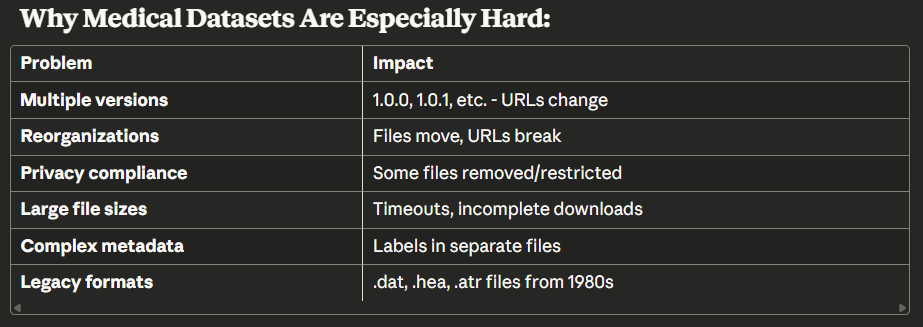